## Part 1

#### Libraries

In [1]:
import pandas as pd

#### Load the Dataset

In [2]:
orders = pd.read_csv('List_of_orders.csv')
order_details = pd.read_csv('Order_details.csv')

#### Merge Dataset

In [3]:
df = pd.merge(orders,order_details, on = 'Order ID' , how = 'inner')

In [4]:
df

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases
1,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole
2,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief
3,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games
4,B-25602,01-04-2018,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones
...,...,...,...,...,...,...,...,...,...,...
1495,B-26099,30-03-2019,Bhishm,Maharashtra,Mumbai,835,267,5,Electronics,Phones
1496,B-26099,30-03-2019,Bhishm,Maharashtra,Mumbai,2366,552,5,Clothing,Trousers
1497,B-26100,31-03-2019,Hitika,Madhya Pradesh,Indore,828,230,2,Furniture,Chairs
1498,B-26100,31-03-2019,Hitika,Madhya Pradesh,Indore,34,10,2,Clothing,T-shirt


##### Total Sales (Amount) for each category

In [5]:
total_sales = df.groupby('Category')['Amount'].sum().reset_index()
total_sales.rename(columns= {'Amount':'Total Sales'}, inplace = True)
total_sales

,Category,Total Sales
0,Clothing,139054
1,Electronics,165267
2,Furniture,127181


#### Average Profit per Order & Total Profit Margin per Category

In [6]:
category_profit = df.groupby('Category').agg(
    Total_Profit = ('Profit', 'sum'),
    Avg_Profit_Per_Order = ('Profit', 'mean'),
    Total_Sales = ('Amount', 'sum')
).reset_index()

# Profit Margin = Profit / Sales * 100
category_profit['Profit_Margin_%'] = (category_profit['Total_Profit'] / 
                                      category_profit['Total_Sales']) * 100

category_profit


,Category,Total_Profit,Avg_Profit_Per_Order,Total_Sales,Profit_Margin_%
0,Clothing,11163,11.762908,139054,8.027817
1,Electronics,10494,34.071429,165267,6.349725
2,Furniture,2298,9.456790,127181,1.806874


#### Identifying Top-Performing & Underperforming Categories

In [7]:
category_profit_sorted = category_profit.sort_values(by= 'Profit_Margin_%',ascending = False)
category_profit_sorted

,Category,Total_Profit,Avg_Profit_Per_Order,Total_Sales,Profit_Margin_%
0,Clothing,11163,11.762908,139054,8.027817
1,Electronics,10494,34.071429,165267,6.349725
2,Furniture,2298,9.456790,127181,1.806874


In [8]:
top_performing = category_profit_sorted.iloc[0]
under_performing = category_profit_sorted.iloc[-1]
print("Top Performing Category:\n",top_performing)
print("Under Performing Category:\n",under_performing)

Top Performing Category:
 Category                 Clothing
Total_Profit                11163
Avg_Profit_Per_Order    11.762908
Total_Sales                139054
Profit_Margin_%          8.027817
Name: 0, dtype: object
Under Performing Category:
 Category                Furniture
Total_Profit                 2298
Avg_Profit_Per_Order      9.45679
Total_Sales                127181
Profit_Margin_%          1.806874
Name: 2, dtype: object


#### reasons for their performance differences 


Higher selling price \
High demand / frequent orders \
Better cost control → higher profit margin \
Strong supplier relationships or bulk purchase discounts

## Part 2

In [59]:
df1 = pd.read_csv("Sales_target.csv")
df1

,Month of Order Date,Category,Target
0,Apr-18,Furniture,10400
1,May-18,Furniture,10500
2,Jun-18,Furniture,10600
3,Jul-18,Furniture,10800
4,Aug-18,Furniture,10900
5,Sep-18,Furniture,11000
6,Oct-18,Furniture,11100
7,Nov-18,Furniture,11300
8,Dec-18,Furniture,11400
9,Jan-19,Furniture,11500


In [60]:
furniture = df1[df1['Category']=='Furniture'].copy()

In [61]:
furniture['Month of Order Date'] = pd.to_datetime(furniture['Month of Order Date'], format='%b-%y')


In [62]:
furniture = furniture.sort_values(by = 'Month of Order Date')

In [63]:
furniture['Month of Order Date'] = furniture['Month of Order Date'].dt.strftime('%b %Y')
furniture

,Month of Order Date,Category,Target
0,Apr 2018,Furniture,10400
1,May 2018,Furniture,10500
2,Jun 2018,Furniture,10600
3,Jul 2018,Furniture,10800
4,Aug 2018,Furniture,10900
5,Sep 2018,Furniture,11000
6,Oct 2018,Furniture,11100
7,Nov 2018,Furniture,11300
8,Dec 2018,Furniture,11400
9,Jan 2019,Furniture,11500


In [66]:
furniture['Prev_Target'] = furniture['Target'].shift(1)

In [67]:
furniture['MoM_%_Change'] = ((furniture['Target'] - furniture['Prev_Target']) /
                             furniture['Prev_Target']) * 100

In [68]:
furniture

,Month of Order Date,Category,Target,Prev_Target,MoM_%_Change
0,Apr 2018,Furniture,10400,NaN,NaN
1,May 2018,Furniture,10500,10400.0,0.961538
2,Jun 2018,Furniture,10600,10500.0,0.952381
3,Jul 2018,Furniture,10800,10600.0,1.886792
4,Aug 2018,Furniture,10900,10800.0,0.925926
5,Sep 2018,Furniture,11000,10900.0,0.917431
6,Oct 2018,Furniture,11100,11000.0,0.909091
7,Nov 2018,Furniture,11300,11100.0,1.801802
8,Dec 2018,Furniture,11400,11300.0,0.884956
9,Jan 2019,Furniture,11500,11400.0,0.877193


## Part 3

In [80]:
df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases
1,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole
2,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief
3,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games
4,B-25602,01-04-2018,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones


In [86]:
top_states = (df['State'].value_counts().head(5).reset_index())
top_state_columns = ['State', 'Order_count']
top_states

,State,count
0,Madhya Pradesh,340
1,Maharashtra,290
2,Gujarat,87
3,Rajasthan,74
4,Delhi,74


In [87]:
top_state_list = top_states['State'].tolist()
filtered = df[df['State'].isin(top_state_list)]

In [92]:
state_metrics = (filtered.groupby('State').agg(
    Total_Sales = ('Amount','sum'),
    Avergae_profit= ('Profit','mean'),
    order_count = ('Order ID','count')).sort_values(by='order_count', ascending =False)
)
state_metrics

,Total_Sales,Avergae_profit,order_count
State,,,
Madhya Pradesh,105140,16.326471,340
Maharashtra,95348,21.296552,290
Gujarat,21058,5.344828,87
Delhi,22531,40.364865,74
Rajasthan,21149,16.986486,74


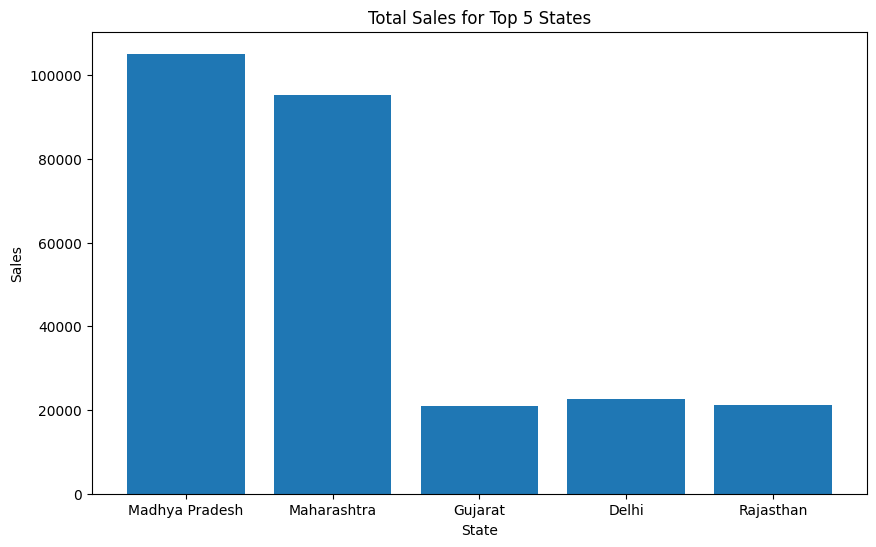

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(state_metrics.index, state_metrics['Total_Sales'])
plt.title("Total Sales for Top 5 States")
plt.xlabel("State")
plt.ylabel("Sales")
plt.show()


In [96]:
bottom_states = (df['State'].value_counts().tail(10).reset_index())
bottom_state_columns = ['State', 'Order_count']
bottom_states

,State,count
0,Karnataka,54
1,Jammu and Kashmir,49
2,Nagaland,45
3,Kerala,45
4,Goa,43
5,Andhra Pradesh,42
6,Himachal Pradesh,29
7,Haryana,26
8,Tamil Nadu,25
9,Sikkim,24


In [97]:
bottom_state_list = bottom_states['State'].tolist()
filtered = df[df['State'].isin(bottom_state_list)]

In [98]:
state_metrics = (filtered.groupby('State').agg(
    Total_Sales = ('Amount','sum'),
    Avergae_profit= ('Profit','mean'),
    order_count = ('Order ID','count')).sort_values(by='order_count', ascending =False)
)
state_metrics

,Total_Sales,Avergae_profit,order_count
State,,,
Karnataka,15058,11.944444,54
Jammu and Kashmir,10829,0.163265,49
Nagaland,11903,3.288889,45
Kerala,13459,41.577778,45
Goa,6705,8.604651,43
Andhra Pradesh,13256,-11.809524,42
Himachal Pradesh,8666,22.620690,29
Haryana,8863,50.961538,26
Tamil Nadu,6087,-88.640000,25


### 1. High Order Count but Overall Loss  
States such as Andhra Pradesh and Tamil Nadu have a high number of orders, indicating strong customer demand. \
However, despite the high sales volume, these states are operating at a loss.

#### Possible Reasons 
Heavy discounting to attract customers \
High shipping/logistics costs \
High return rate or damaged products \
Low pricing compared to cost of goods \
Unoptimized supply chain or regional warehouses \

#### Recommendation
Adjust product prices to better reflect logistics and demand \
Reduce frequent discounts \
Introduce region-specific delivery charges \
Identify products causing maximum loss and reprice them \
Improve warehouse placement to reduce transportation cost \

### 2. Good Order Count but Very Low Profit
States such as Jammu & Kashmir, Nagaland, and Goa show moderately good order counts, but their profit margins are very low. \

#### Possible Reasons
High delivery costs due to geographic challenges \
Product mix dominated by low-profit items \
Extra costs for remote locations \
Higher return/shipping back fees \
Demand mainly for discounted or low-margin products \

#### Recommendation
Review product assortment—promote higher-margin items \
Introduce minimum order value for free delivery \
Negotiate better courier service pricing \
Optimize inventory routing \
Offer bundled products to increase average order value \
